# Iris Species Classification

This notebook builds and compares classic machine-learning classifiers for the Iris dataset using sepal and petal measurements.

It covers:
- Exploratory data analysis and class separability visuals
- Training and comparing k-NN, Logistic Regression, and Decision Tree models
- Accuracy, confusion matrix, precision, and recall
- Saving the best-performing model for reuse


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = Path("IRIS.csv")
MODEL_PATH = Path("iris_best_model.joblib")

# Load the dataset
df = pd.read_csv(DATA_PATH)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Exploratory Data Analysis

The Iris dataset is a classic example where petal measurements separate the classes much more clearly than sepal measurements. The plots below highlight that structure.

Shape: (150, 5)
Class distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


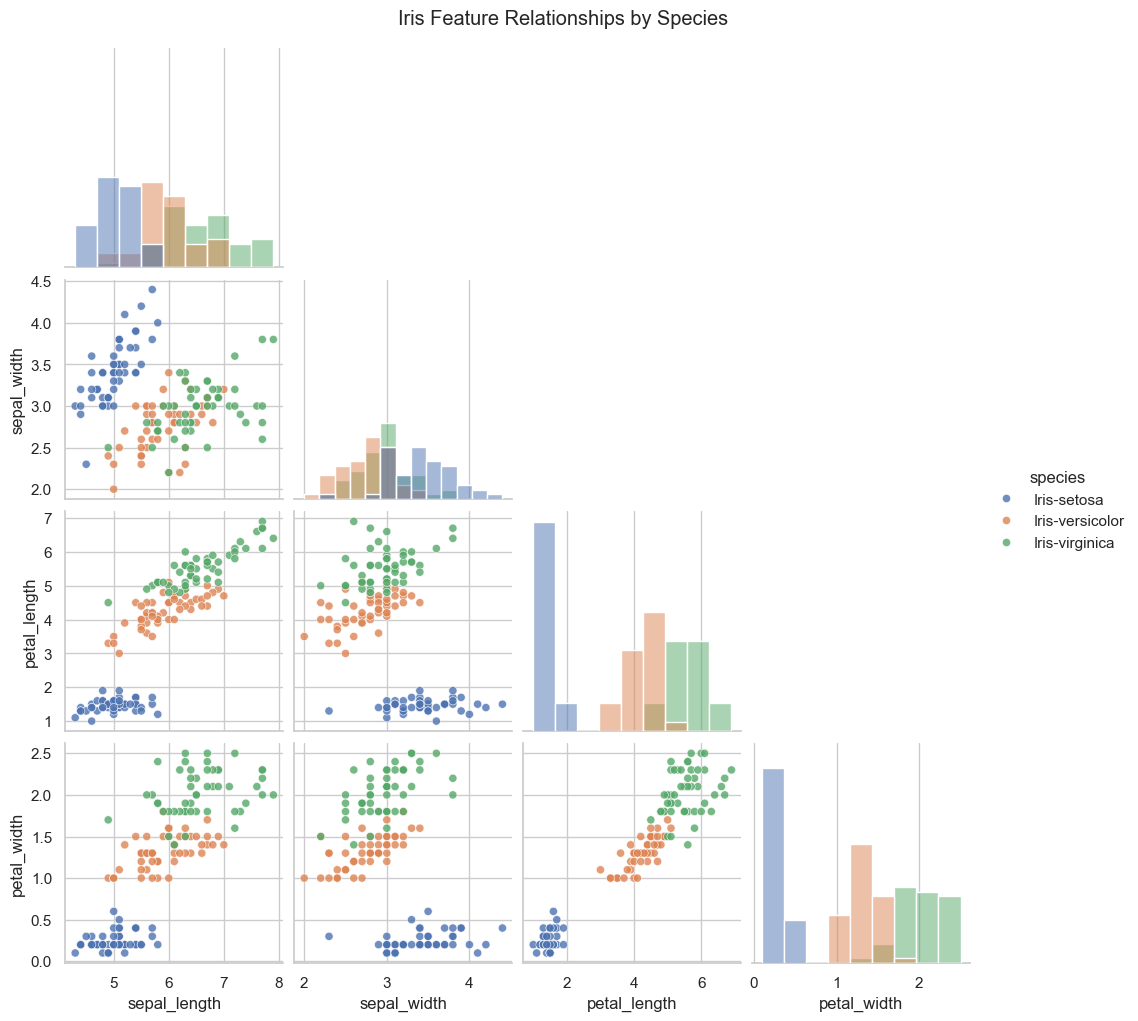

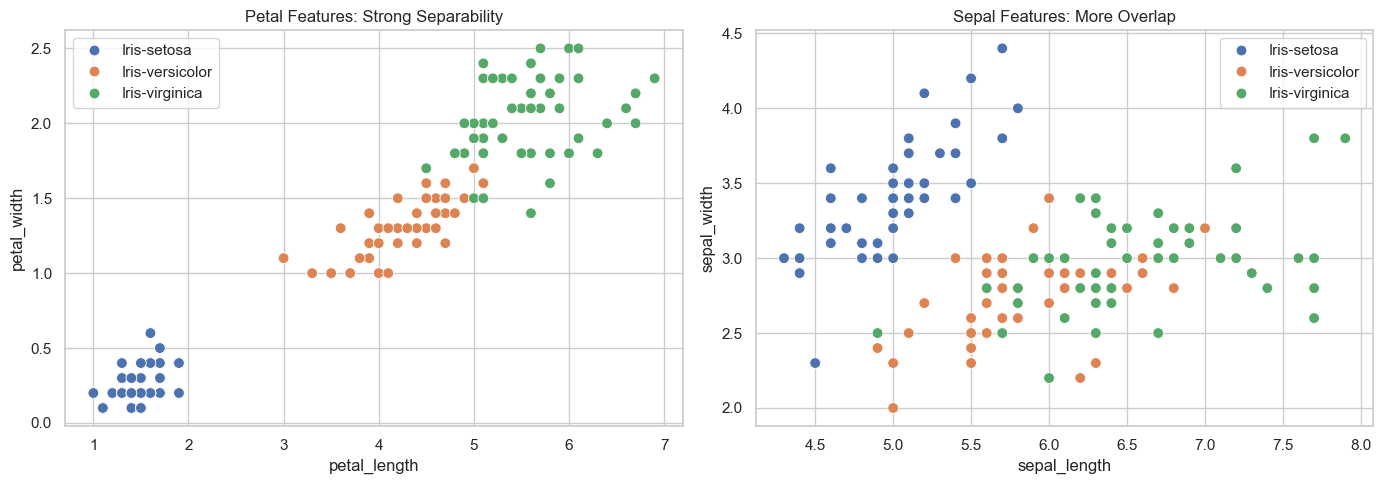

In [2]:
# Basic dataset checks
print(f"Shape: {df.shape}")
print("Class distribution:")
print(df["species"].value_counts())
print("\nMissing values:\n", df.isna().sum())

# Class separability visuals
sns.pairplot(df, hue="species", diag_kind="hist", corner=True, plot_kws={"alpha": 0.8, "s": 35})
plt.suptitle("Iris Feature Relationships by Species", y=1.02)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", ax=axes[0], s=60)
axes[0].set_title("Petal Features: Strong Separability")
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", hue="species", ax=axes[1], s=60)
axes[1].set_title("Sepal Features: More Overlap")
for ax in axes:
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

## Model Training and Comparison

We compare three classifiers using the same train/test split and report accuracy, precision, recall, and confusion matrix results for each.

In [3]:
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = df[feature_cols]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

models = {
    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

results = []
trained_models = {}
classes = sorted(y.unique())

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    trained_models[name] = model
    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, predictions),
            "precision": precision_score(y_test, predictions, average="weighted", zero_division=0),
            "recall": recall_score(y_test, predictions, average="weighted", zero_division=0),
        }
    )

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall
0,k-NN,0.933333,0.944444,0.933333
1,Logistic Regression,0.933333,0.933333,0.933333
2,Decision Tree,0.933333,0.933333,0.933333


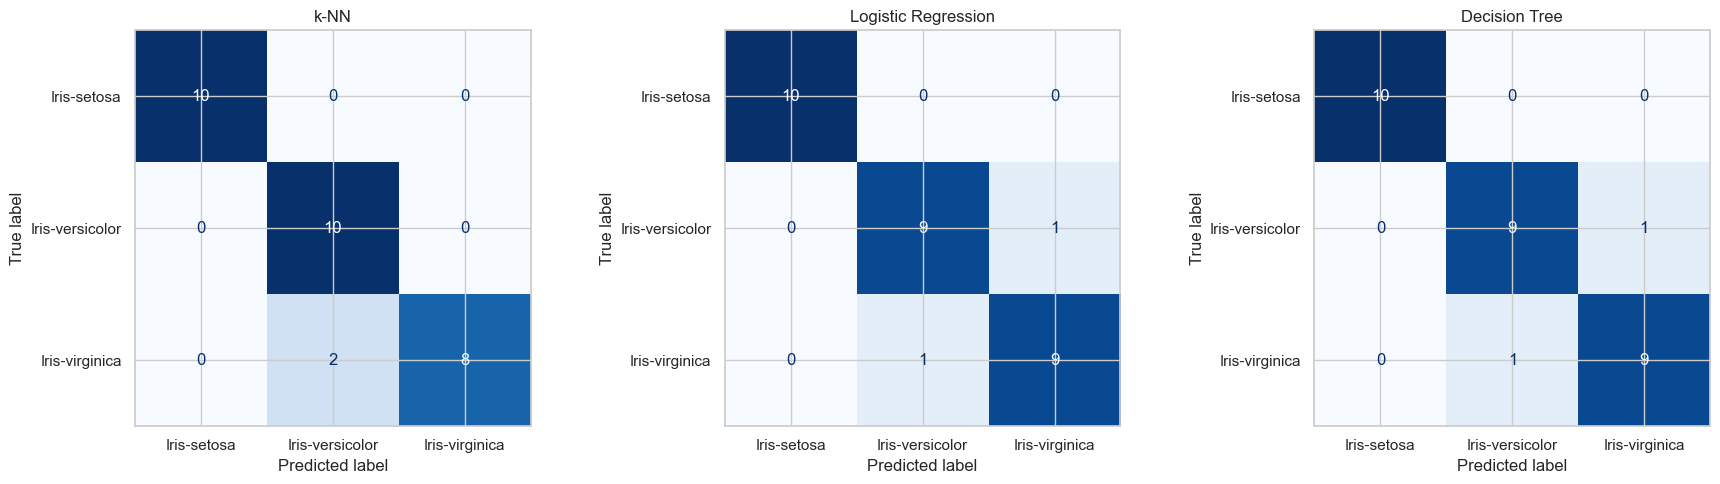

Best model: k-NN
Saved to: C:\Users\HP\Jupyter\InternShala_ML\IrisCLassification\iris_best_model.joblib


model            k-NN
accuracy     0.933333
precision    0.944444
recall       0.933333
Name: 0, dtype: object

In [4]:
# Show confusion matrices for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    predictions = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=classes,
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

# Pick the best model by accuracy and save it
best_row = results_df.iloc[0]
best_name = best_row["model"]
best_model = trained_models[best_name]
joblib.dump(best_model, MODEL_PATH)

print(f"Best model: {best_name}")
print(f"Saved to: {MODEL_PATH.resolve()}")
best_row

## Inference Example

Use the saved pipeline to classify new Iris measurements with the same feature order used during training.

In [5]:
loaded_model = joblib.load(MODEL_PATH)

sample = pd.DataFrame(
    [[5.8, 2.7, 5.1, 1.9]],
    columns=feature_cols,
)

prediction = loaded_model.predict(sample)[0]
probabilities = getattr(loaded_model, "predict_proba", None)

print("Sample:")
print(sample)
print(f"Predicted species: {prediction}")
if callable(probabilities):
    print("Class probabilities:")
    print(loaded_model.predict_proba(sample))

Sample:
   sepal_length  sepal_width  petal_length  petal_width
0           5.8          2.7           5.1          1.9
Predicted species: Iris-virginica
Class probabilities:
[[0.  0.2 0.8]]
